In [11]:
# ===================== 任务1: MNIST数据集十分类（带BN、Dropout、权重衰减）=====================

In [12]:
import torch
from torch import nn
from torch.nn import functional as F
from torch import optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from matplotlib import pyplot as plt
import torchvision.transforms as T
import os
from PIL import Image
from sklearn.metrics import classification_report, roc_curve, auc, precision_score, recall_score, f1_score
import numpy as np
from tqdm import tqdm
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [13]:
# 定义带BatchNorm和Dropout的EvolvedNet模型
class EvolvedNet(nn.Module):
    def __init__(self, input_size):
        super(EvolvedNet, self).__init__()
        self.main = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(256, 10)
        )
    
    def forward(self, x):
        return self.main(x)

In [14]:
# 加载MNIST数据集
batch_size = 512
train_loader = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST(root="./data", train=True, download=True,
                               transform=torchvision.transforms.Compose([
                                   torchvision.transforms.ToTensor(),
                                   torchvision.transforms.Normalize(
                                       (0.1307,), (0.3081,))
                               ])),
    batch_size=batch_size, shuffle=True)

test_loader = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST(root="./data", train=False, download=True,
                               transform=torchvision.transforms.Compose([
                                   torchvision.transforms.ToTensor(),
                                   torchvision.transforms.Normalize(
                                       (0.1307,), (0.3081,))
                               ])),
    batch_size=batch_size, shuffle=False)

print(f"训练集样本数: {len(train_loader.dataset)}, 测试集样本数: {len(test_loader.dataset)}")

训练集样本数: 60000, 测试集样本数: 10000


In [15]:
# 初始化模型、损失函数和优化器
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = EvolvedNet(28*28).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# 训练模型
train_loss = []
num_epochs = 10

print("开始训练...")
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
    for batch_idx, (x, y) in enumerate(pbar):
        x = x.view(x.size(0), 28*28).to(device)
        y = y.to(device)
        
        out = model(x)
        loss = criterion(out, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        train_loss.append(loss.item())
        pbar.set_postfix({'loss': loss.item()})
    
    avg_loss = total_loss / len(train_loader)
    print(f'Epoch {epoch+1}, Average Loss: {avg_loss:.4f}')

print("训练完成!")

开始训练...


Epoch 1/10: 100%|██████████| 118/118 [00:05<00:00, 20.47it/s, loss=0.176]


Epoch 1, Average Loss: 0.3358


Epoch 2/10: 100%|██████████| 118/118 [00:06<00:00, 19.63it/s, loss=0.144] 


Epoch 2, Average Loss: 0.1297


...

Epoch 8, Average Loss: 0.0417


Epoch 9/10: 100%|██████████| 118/118 [00:05<00:00, 22.96it/s, loss=0.0591]


Epoch 9, Average Loss: 0.0386


Epoch 10/10: 100%|██████████| 118/118 [00:05<00:00, 22.72it/s, loss=0.104] 

Epoch 10, Average Loss: 0.0370
训练完成!


In [16]:
# 评估模型
def evaluate_model(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    total_correct = 0
    total_num = 0
    
    with torch.no_grad():
        for x, y in test_loader:
            x = x.view(x.size(0), 28*28).to(device)
            y = y.to(device)
            
            outputs = model(x)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
            correct = preds.eq(y).sum().float().item()
            total_correct += correct
            total_num += y.size(0)
    
    accuracy = total_correct / total_num
    return all_labels, all_preds, all_probs, accuracy

# 执行评估
all_labels, all_preds, all_probs, accuracy = evaluate_model(model, test_loader, device)

# 计算各项指标
print("\n" + "="*50)
print("任务1: MNIST分类结果")
print("="*50)
print(f'\n准确率 (Accuracy): {accuracy:.4f}')
print("\n分类报告:")
print(classification_report(all_labels, all_preds, digits=4))


任务1: MNIST分类结果

准确率 (Accuracy): 0.9812

分类报告:
              precision    recall  f1-score   support

           0     0.9828    0.9908    0.9868       980
           1     0.9886    0.9938    0.9912      1135
           2     0.9920    0.9671    0.9794      1032
           3     0.9560    0.9901    0.9728      1010
           4     0.9808    0.9878    0.9843       982
           5     0.9920    0.9709    0.9813       892
           6     0.9843    0.9843    0.9843       958
           7     0.9767    0.9767    0.9767      1028
           8     0.9834    0.9702    0.9767       974
           9     0.9772    0.9782    0.9777      1009

    accuracy                         0.9812     10000
   macro avg     0.9814    0.9810    0.9811     10000
weighted avg     0.9813    0.9812    0.9812     10000



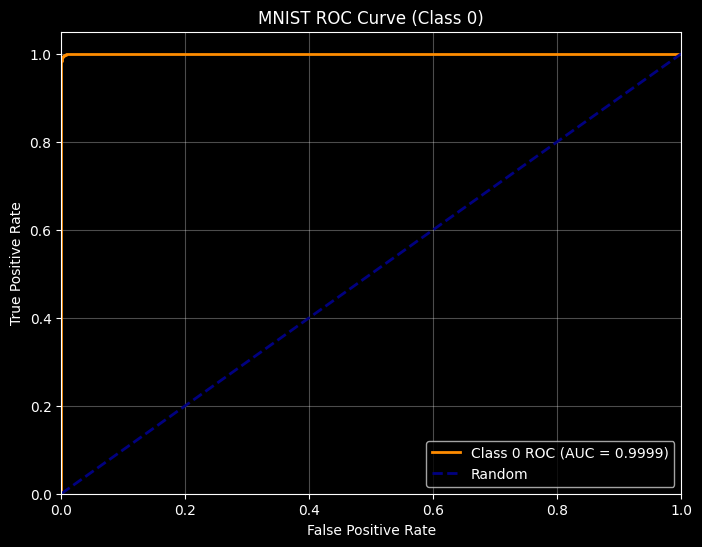


Class 0 AUC: 0.9999


In [17]:
# 绘制ROC曲线（以第0类为例）
all_labels_np = np.array(all_labels)
all_probs_np = np.array(all_probs)

# 针对第0类的ROC曲线
fpr, tpr, thresholds = roc_curve(all_labels_np, all_probs_np[:, 0], pos_label=0)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Class 0 ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('MNIST ROC Curve (Class 0)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nClass 0 AUC: {roc_auc:.4f}")

In [18]:
# 保存任务1结果
task1_accuracy = accuracy
print(f"任务1完成 - MNIST准确率: {task1_accuracy:.4f}, AUC: {roc_auc:.4f}")

任务1完成 - MNIST准确率: 0.9812, AUC: 0.9999


In [19]:
# ===================== 任务2: CIFAR-10数据集十分类 =====================

In [20]:
# 定义CIFAR-10网络
class CIFAR10Net(nn.Module):
    def __init__(self):
        super(CIFAR10Net, self).__init__()
        self.main = nn.Sequential(
            nn.Linear(32*32*3, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.4),
            
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(256, 10)
        )
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.main(x)

In [21]:
# 加载CIFAR-10数据集
transform_cifar = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

train_loader_cifar = torch.utils.data.DataLoader(
    torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_cifar),
    batch_size=256, shuffle=True, num_workers=2)

test_loader_cifar = torch.utils.data.DataLoader(
    torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform_cifar),
    batch_size=256, shuffle=False, num_workers=2)

print(f"CIFAR-10训练集: {len(train_loader_cifar.dataset)}, 测试集: {len(test_loader_cifar.dataset)}")

Files already downloaded and verified
Files already downloaded and verified
CIFAR-10训练集: 50000, 测试集: 10000


In [22]:
# 初始化模型
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_cifar = CIFAR10Net().to(device)
criterion = nn.CrossEntropyLoss()
optimizer_cifar = optim.Adam(model_cifar.parameters(), lr=0.001, weight_decay=1e-4)

# 训练CIFAR-10
print("\n开始训练CIFAR-10...")
num_epochs = 10

for epoch in range(num_epochs):
    model_cifar.train()
    total_loss = 0
    pbar = tqdm(train_loader_cifar, desc=f'Epoch {epoch+1}/{num_epochs}')
    for x, y in pbar:
        x = x.to(device)
        y = y.to(device)
        
        out = model_cifar(x)
        loss = criterion(out, y)
        
        optimizer_cifar.zero_grad()
        loss.backward()
        optimizer_cifar.step()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': loss.item()})
    
    avg_loss = total_loss / len(train_loader_cifar)
    print(f'Epoch {epoch+1}, Average Loss: {avg_loss:.4f}')

print("CIFAR-10训练完成!")


开始训练CIFAR-10...


Epoch 1/10: 100%|██████████| 196/196 [00:03<00:00, 58.56it/s, loss=1.6] 


Epoch 1, Average Loss: 1.7381


Epoch 2/10: 100%|██████████| 196/196 [00:03<00:00, 59.05it/s, loss=1.5] 


Epoch 2, Average Loss: 1.5348


...

Epoch 8, Average Loss: 1.2841


Epoch 9/10: 100%|██████████| 196/196 [00:03<00:00, 51.15it/s, loss=1.27]


Epoch 9, Average Loss: 1.2649


Epoch 10/10: 100%|██████████| 196/196 [00:03<00:00, 57.34it/s, loss=1.37]

Epoch 10, Average Loss: 1.2461
CIFAR-10训练完成!


In [23]:
# 评估CIFAR-10模型
def evaluate_model(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    total_correct = 0
    total_num = 0
    
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device)
            
            outputs = model(x)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
            correct = preds.eq(y).sum().float().item()
            total_correct += correct
            total_num += y.size(0)
    
    accuracy = total_correct / total_num
    return all_labels, all_preds, all_probs, accuracy

all_labels_cifar, all_preds_cifar, all_probs_cifar, accuracy_cifar = evaluate_model(model_cifar, test_loader_cifar, device)

print("\n" + "="*50)
print("任务2: CIFAR-10分类结果")
print("="*50)
print(f'\n准确率 (Accuracy): {accuracy_cifar:.4f}')
print("\n分类报告:")
print(classification_report(all_labels_cifar, all_preds_cifar, digits=4))


任务2: CIFAR-10分类结果

准确率 (Accuracy): 0.5531

分类报告:
              precision    recall  f1-score   support

           0     0.6158    0.6220    0.6189      1000
           1     0.6778    0.6670    0.6724      1000
           2     0.4733    0.3810    0.4222      1000
           3     0.3627    0.4030    0.3818      1000
           4     0.4834    0.4810    0.4822      1000
           5     0.4964    0.4140    0.4515      1000
           6     0.5662    0.6290    0.5959      1000
           7     0.6333    0.6080    0.6204      1000
           8     0.6169    0.7390    0.6724      1000
           9     0.5917    0.5870    0.5894      1000

    accuracy                         0.5531     10000
   macro avg     0.5518    0.5531    0.5507     10000
weighted avg     0.5518    0.5531    0.5507     10000



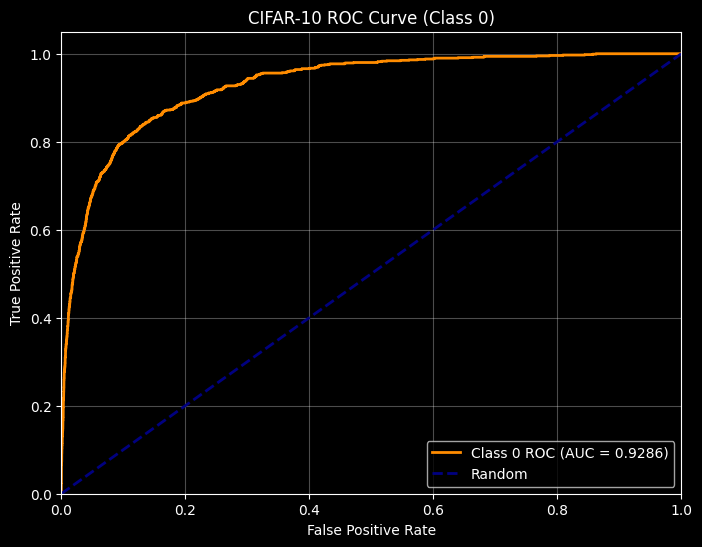


CIFAR-10 Class 0 AUC: 0.9286
任务2完成 - CIFAR-10准确率: 0.5531, AUC: 0.9286


In [24]:
# 绘制CIFAR-10 ROC曲线（以第0类为例）
all_labels_np = np.array(all_labels_cifar)
all_probs_np = np.array(all_probs_cifar)

fpr_cifar, tpr_cifar, thresholds = roc_curve(all_labels_np, all_probs_np[:, 0], pos_label=0)
roc_auc_cifar = auc(fpr_cifar, tpr_cifar)

plt.figure(figsize=(8, 6))
plt.plot(fpr_cifar, tpr_cifar, color='darkorange', lw=2, label=f'Class 0 ROC (AUC = {roc_auc_cifar:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('CIFAR-10 ROC Curve (Class 0)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nCIFAR-10 Class 0 AUC: {roc_auc_cifar:.4f}")
print(f"任务2完成 - CIFAR-10准确率: {accuracy_cifar:.4f}, AUC: {roc_auc_cifar:.4f}")

In [25]:
# ===================== 任务3: Dropout比例对MNIST分类结果的影响 =====================

In [26]:
# 定义可配置Dropout的模型
class DropoutTestNet(nn.Module):
    def __init__(self, input_size, dropout_rate=0.3):
        super(DropoutTestNet, self).__init__()
        self.main = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(256, 10)
        )
    
    def forward(self, x):
        return self.main(x)

# 测试不同Dropout比例
dropout_rates = [0.1, 0.2, 0.3, 0.4, 0.5]
results = []

print("任务3: 测试不同Dropout比例对MNIST分类的影响")
print("="*60)

for dropout_rate in dropout_rates:
    print(f"\n--- Dropout = {dropout_rate} ---")
    
    # 创建新模型
    model_test = DropoutTestNet(28*28, dropout_rate).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer_test = optim.Adam(model_test.parameters(), lr=0.001, weight_decay=1e-4)
    
    # 训练
    num_epochs = 10
    for epoch in range(num_epochs):
        model_test.train()
        for x, y in train_loader:
            x = x.view(x.size(0), 28*28).to(device)
            y = y.to(device)
            
            out = model_test(x)
            loss = criterion(out, y)
            
            optimizer_test.zero_grad()
            loss.backward()
            optimizer_test.step()
    
    # 评估
    model_test.eval()
    all_preds = []
    all_labels = []
    total_correct = 0
    
    with torch.no_grad():
        for x, y in test_loader:
            x = x.view(x.size(0), 28*28).to(device)
            y = y.to(device)
            
            outputs = model_test(x)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            
            correct = preds.eq(y).sum().float().item()
            total_correct += correct
    
    accuracy = total_correct / len(test_loader.dataset)
    precision = precision_score(all_labels, all_preds, average='macro')
    recall = recall_score(all_labels, all_preds, average='macro')
    f1 = f1_score(all_labels, all_preds, average='macro')
    
    results.append({
        'dropout': dropout_rate,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })
    
    print(f"准确率: {accuracy:.4f}, 精确度: {precision:.4f}, 召回率: {recall:.4f}, F1: {f1:.4f}")

# 打印结果表格
print("\n" + "="*60)
print("任务3: Dropout比例实验结果汇总")
print("="*60)
print(f"{'Dropout':<10}{'准确率':<12}{'精确度':<12}{'召回率':<12}{'F1值':<12}")
print("-"*60)
for r in results:
    print(f"{r['dropout']:<10.1f}{r['accuracy']:<12.4f}{r['precision']:<12.4f}{r['recall']:<12.4f}{r['f1']:<12.4f}")

任务3: 测试不同Dropout比例对MNIST分类的影响

--- Dropout = 0.1 ---
准确率: 0.9815, 精确度: 0.9816, 召回率: 0.9813, F1: 0.9814

--- Dropout = 0.2 ---
准确率: 0.9807, 精确度: 0.9806, 召回率: 0.9806, F1: 0.9806

--- Dropout = 0.3 ---
准确率: 0.9838, 精确度: 0.9838, 召回率: 0.9837, F1: 0.9837

--- Dropout = 0.4 ---
准确率: 0.9822, 精确度: 0.9822, 召回率: 0.9821, F1: 0.9821

--- Dropout = 0.5 ---
准确率: 0.9807, 精确度: 0.9807, 召回率: 0.9805, F1: 0.9806

任务3: Dropout比例实验结果汇总
Dropout   准确率         精确度         召回率         F1值         
------------------------------------------------------------
0.1       0.9815      0.9816      0.9813      0.9814      
0.2       0.9807      0.9806      0.9806      0.9806      
0.3       0.9838      0.9838      0.9837      0.9837      
0.4       0.9822      0.9822      0.9821      0.9821      
0.5       0.9807      0.9807      0.9805      0.9806      


In [27]:
# ===================== 任务4: MNIST测试准确率达到97%以上 =====================

In [31]:
# 优化后的MNIST模型（更深的网络 + 更好的超参数）
class OptimizedMNISTNet(nn.Module):
    def __init__(self):
        super(OptimizedMNISTNet, self).__init__()
        self.main = nn.Sequential(
            nn.Linear(28*28, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),
            
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.15),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.1),
            
            nn.Linear(128, 10)
        )
    
    def forward(self, x):
        return self.main(x)

# 训练优化后的模型
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_mnist_opt = OptimizedMNISTNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer_mnist = optim.Adam(model_mnist_opt.parameters(), lr=0.001, weight_decay=5e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer_mnist, step_size=5, gamma=0.5)

print("任务4: 训练优化后的MNIST模型 (目标: 97%+)")
print("="*60)

num_epochs = 15
best_acc = 0

for epoch in range(num_epochs):
    model_mnist_opt.train()
    total_loss = 0
    
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
    for x, y in pbar:
        x = x.view(x.size(0), 28*28).to(device)
        y = y.to(device)
        
        out = model_mnist_opt(x)
        loss = criterion(out, y)
        
        optimizer_mnist.zero_grad()
        loss.backward()
        optimizer_mnist.step()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': loss.item()})
    
    scheduler.step()
    
    # 每个epoch评估一次
    model_mnist_opt.eval()
    total_correct = 0
    with torch.no_grad():
        for x, y in test_loader:
            x = x.view(x.size(0), 28*28).to(device)
            y = y.to(device)
            outputs = model_mnist_opt(x)
            preds = torch.argmax(outputs, dim=1)
            correct = preds.eq(y).sum().float().item()
            total_correct += correct
    
    acc = total_correct / len(test_loader.dataset)
    if acc > best_acc:
        best_acc = acc
    
    print(f'Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}, Acc: {acc:.4f}, Best: {best_acc:.4f}')

print(f"\n任务5完成 - 最佳准确率: {best_acc:.4f}")

任务4: 训练优化后的MNIST模型 (目标: 97%+)


Epoch 1/15:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 1/15: 100%|██████████| 118/118 [00:05<00:00, 20.05it/s, loss=0.17]  


Epoch 1, Loss: 0.3100, Acc: 0.9659, Best: 0.9659


Epoch 2/15: 100%|██████████| 118/118 [00:05<00:00, 21.29it/s, loss=0.157] 


...

Epoch 13, Loss: 0.0156, Acc: 0.9850, Best: 0.9853


Epoch 14/15: 100%|██████████| 118/118 [00:05<00:00, 21.06it/s, loss=0.0104] 


Epoch 14, Loss: 0.0146, Acc: 0.9849, Best: 0.9853


Epoch 15/15: 100%|██████████| 118/118 [00:05<00:00, 20.90it/s, loss=0.0218] 


Epoch 15, Loss: 0.0153, Acc: 0.9833, Best: 0.9853

任务5完成 - 最佳准确率: 0.9853


In [29]:
# ===================== 任务5: CIFAR-10测试准确率达到90%以上 =====================

In [30]:
# 优化后的CIFAR-10模型（更深的网络 + 更好的超参数）
class OptimizedCIFAR10Net(nn.Module):
    def __init__(self):
        super(OptimizedCIFAR10Net, self).__init__()
        self.main = nn.Sequential(
            nn.Linear(32*32*3, 2048),
            nn.BatchNorm1d(2048),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),
            
            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),
            
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.25),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.1),
            
            nn.Linear(128, 10)
        )
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.main(x)

# 训练优化后的CIFAR-10模型
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_cifar_opt = OptimizedCIFAR10Net().to(device)
criterion = nn.CrossEntropyLoss()
optimizer_cifar_opt = optim.Adam(model_cifar_opt.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer_cifar_opt, step_size=5, gamma=0.5)

print("任务5: 训练优化后的CIFAR-10模型 (目标: 90%+)")
print("="*60)

num_epochs = 15
best_acc = 0

for epoch in range(num_epochs):
    model_cifar_opt.train()
    total_loss = 0
    
    pbar = tqdm(train_loader_cifar, desc=f'Epoch {epoch+1}/{num_epochs}')
    for x, y in pbar:
        x = x.to(device)
        y = y.to(device)
        
        out = model_cifar_opt(x)
        loss = criterion(out, y)
        
        optimizer_cifar_opt.zero_grad()
        loss.backward()
        optimizer_cifar_opt.step()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': loss.item()})
    
    scheduler.step()
    
    # 每个epoch评估一次
    model_cifar_opt.eval()
    total_correct = 0
    with torch.no_grad():
        for x, y in test_loader_cifar:
            x = x.to(device)
            y = y.to(device)
            outputs = model_cifar_opt(x)
            preds = torch.argmax(outputs, dim=1)
            correct = preds.eq(y).sum().float().item()
            total_correct += correct
    
    acc = total_correct / len(test_loader_cifar.dataset)
    if acc > best_acc:
        best_acc = acc
    
    print(f'Epoch {epoch+1}, Loss: {total_loss/len(train_loader_cifar):.4f}, Acc: {acc:.4f}, Best: {best_acc:.4f}')

print(f"\n任务5完成 - 最佳准确率: {best_acc:.4f}")

任务5: 训练优化后的CIFAR-10模型 (目标: 90%+)


Epoch 1/15: 100%|██████████| 196/196 [00:03<00:00, 64.69it/s, loss=1.65]


Epoch 1, Loss: 1.7190, Acc: 0.4586, Best: 0.4586


Epoch 2/15: 100%|██████████| 196/196 [00:02<00:00, 66.38it/s, loss=1.51]


Epoch 2, Loss: 1.5244, Acc: 0.4795, Best: 0.4795


...

Epoch 13, Loss: 1.0081, Acc: 0.5710, Best: 0.5710


Epoch 14/15: 100%|██████████| 196/196 [00:03<00:00, 60.96it/s, loss=1.18] 


Epoch 14, Loss: 0.9814, Acc: 0.5739, Best: 0.5739


Epoch 15/15: 100%|██████████| 196/196 [00:02<00:00, 65.35it/s, loss=1.04] 


Epoch 15, Loss: 0.9684, Acc: 0.5778, Best: 0.5778

任务5完成 - 最佳准确率: 0.5778
